<a href="https://colab.research.google.com/github/rogoraul/Proyecto-Concrete/blob/main/notebooks/03_Modelos_Complejos_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Concrete Crack Images for Classification

---

In [1]:
# Cargamos las librerias necesarias
import sys
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import os
import zipfile
import shutil
import pandas as pd
import seaborn as sns
from PIL import Image
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from google.colab import files
from keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint, CSVLogger
import kagglehub
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import img_to_array, load_img
import tensorflow as tf
from tensorflow.keras.metrics import Recall, AUC, Precision
from tensorflow.keras.applications.resnet50 import preprocess_input
from sklearn.metrics import roc_curve, auc

In [2]:
# Descarga de los datos
path = kagglehub.dataset_download("aniruddhsharma/structural-defects-network-concrete-crack-images")
print("Path to dataset files:", path)

os.makedirs('./data', exist_ok=True)

datasets_dl = {'structural_defects': path}

for name, source in datasets_dl.items():
    target = os.path.join('./data', name)
    if not os.path.exists(target):
        os.symlink(source, target)
        print(f'Dataset {name} vinculado en: {target}')
    else:
        print(f'El enlace para {name} ya existe en ./data')

print('\nContenido actual de ./data:', os.listdir('./data'))

100%|██████████| 506M/506M [00:03<00:00, 149MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/aniruddhsharma/structural-defects-network-concrete-crack-images/versions/1
Dataset structural_defects vinculado en: ./data/structural_defects

Contenido actual de ./data: ['structural_defects']


In [3]:
# Fusión de las imagenes en una sola carpeta
structural_defects_path = Path('./data/structural_defects')
merged_path = Path('./data/merged_cracks')
merged_path.mkdir(exist_ok=True)

clases = ['Positive', 'Negative']
for clase in clases:
    (merged_path / clase).mkdir(exist_ok=True)

total_stats = {'Positive': 0, 'Negative': 0}

# Structural Defects (Cracked / Non-cracked × 3)
sd_mapping = {
    'Positive': [
        structural_defects_path / 'Walls' / 'Cracked',
        structural_defects_path / 'Decks' / 'Cracked',
        structural_defects_path / 'Pavements' / 'Cracked',
    ],
    'Negative': [
        structural_defects_path / 'Walls' / 'Non-cracked',
        structural_defects_path / 'Decks' / 'Non-cracked',
        structural_defects_path / 'Pavements' / 'Non-cracked',
    ],
}

for clase, dirs in sd_mapping.items():
    for src_dir in dirs:
        tag = src_dir.parent.name[:2].lower()  # wa, de, pa
        count = 0
        for img_file in src_dir.iterdir():
            if img_file.is_file():
                dest_file = merged_path / clase / f"sd_{tag}_{img_file.name}"
                if not dest_file.exists():
                    shutil.copy2(str(img_file), str(dest_file))
                    count += 1
        total_stats[clase] += count
        print(f"Structural Defects [{src_dir.parent.name}/{src_dir.name}]: +{count}")

# Resumen final
n_pos = len(list((merged_path / 'Positive').iterdir()))
n_neg = len(list((merged_path / 'Negative').iterdir()))
print(f"Dataset fusionado en: {merged_path.resolve()}")
print(f"  Positive (Grieta):    {n_pos}")
print(f"  Negative (Sin Grieta): {n_neg}")
print(f"  Total:                 {n_pos + n_neg}")
if n_pos > 0:
    print(f"  Ratio Neg/Pos:         {n_neg/n_pos:.2f}")
else:
    print("  Ratio Neg/Pos:         N/A")

Structural Defects [Walls/Cracked]: +3851
Structural Defects [Decks/Cracked]: +2025
Structural Defects [Pavements/Cracked]: +2608
Structural Defects [Walls/Non-cracked]: +14287
Structural Defects [Decks/Non-cracked]: +11595
Structural Defects [Pavements/Non-cracked]: +21726
Dataset fusionado en: /content/data/merged_cracks
  Positive (Grieta):    8484
  Negative (Sin Grieta): 47608
  Total:                 56092
  Ratio Neg/Pos:         5.61


In [4]:
# Split en Train, Validation y Test
SOURCE_DIR = Path('./data/merged_cracks')
SPLIT_DIR  = Path('./data/split')

# Recopilar todos los paths y labels
all_paths  = []
all_labels = []

for img_path in sorted((SOURCE_DIR / 'Positive').glob('*.jpg')):
    all_paths.append(img_path)
    all_labels.append(1)
for img_path in sorted((SOURCE_DIR / 'Negative').glob('*.jpg')):
    all_paths.append(img_path)
    all_labels.append(0)

print(f"Total imágenes encontradas: {len(all_paths)}")
print(f"  Positivas: {sum(all_labels)}, Negativas: {len(all_labels) - sum(all_labels)}")

# Split 60% train / 20% val / 20% test
paths_tv, paths_test, y_tv, y_te = train_test_split(
    all_paths, all_labels, test_size=0.2, random_state=42, stratify=all_labels
)
paths_train, paths_val, y_tr, y_va = train_test_split(
    paths_tv, y_tv, test_size=0.25, random_state=42, stratify=y_tv
)

# Crear directorios y copiar archivos
splits = {'train': paths_train, 'val': paths_val, 'test': paths_test}

for split_name, split_paths in splits.items():
    for cls in ['Positive', 'Negative']:
        (SPLIT_DIR / split_name / cls).mkdir(parents=True, exist_ok=True)

    copied = 0
    for p in split_paths:
        cls = p.parent.name
        dest = SPLIT_DIR / split_name / cls / p.name
        if not dest.exists():
            shutil.copy2(str(p), str(dest))
            copied += 1

    total = len(list((SPLIT_DIR / split_name / 'Positive').iterdir())) + \
            len(list((SPLIT_DIR / split_name / 'Negative').iterdir()))
    print(f"\n{split_name.upper()}: {total} imágenes ({copied} copiadas ahora)")
    print(f"  Positive: {len(list((SPLIT_DIR / split_name / 'Positive').iterdir()))}")
    print(f"  Negative: {len(list((SPLIT_DIR / split_name / 'Negative').iterdir()))}")

Total imágenes encontradas: 56092
  Positivas: 8484, Negativas: 47608

TRAIN: 33654 imágenes (33654 copiadas ahora)
  Positive: 5090
  Negative: 28564

VAL: 11219 imágenes (11219 copiadas ahora)
  Positive: 1697
  Negative: 9522

TEST: 11219 imágenes (11219 copiadas ahora)
  Positive: 1697
  Negative: 9522


In [5]:
import importlib

os.makedirs('models', exist_ok=True)

with open('models/cnn_resnet_3.py', 'w') as f:
    f.write("""
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import ResNet50

def build_modelo_resnet_menos_neuronas(input_shape=(227, 227, 3)):
    base_model = ResNet50(weights='imagenet', include_top=False, input_shape=input_shape)
    base_model.trainable = False

    model = models.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(),
        # Reducimos el número de neuronas
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(1, activation='sigmoid')
    ])
    return model
""")

# 3. Añadir al path
sys.path.append('./models')

import cnn_resnet_3
importlib.reload(cnn_resnet_3)

from cnn_resnet_3 import build_modelo_resnet_menos_neuronas

modelo_complejo = build_modelo_resnet_menos_neuronas()
modelo_complejo.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 8, 8, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,850,113 (90.98 MB)

 Trainable params: 262,401 (1.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [6]:
# Carga de datos para entrenamiento
IMG_SIZE = (227, 227)
BATCH_SIZE = 32

datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_gen = datagen.flow_from_directory(
    str(SPLIT_DIR / 'train'), target_size=IMG_SIZE, color_mode='rgb',
    batch_size=BATCH_SIZE, class_mode='binary', shuffle=True, seed=42
)

val_gen = datagen.flow_from_directory(
    str(SPLIT_DIR / 'val'), target_size=IMG_SIZE, color_mode='rgb',
    batch_size=BATCH_SIZE, class_mode='binary', shuffle=False
)

test_gen = datagen.flow_from_directory(
    str(SPLIT_DIR / 'test'), target_size=IMG_SIZE, color_mode='rgb',
    batch_size=BATCH_SIZE, class_mode='binary', shuffle=False
)

Found 33654 images belonging to 2 classes.
Found 11219 images belonging to 2 classes.
Found 11219 images belonging to 2 classes.


In [7]:
from tensorflow.keras.optimizers import Adam
# Compilacion y entrenamiento
model = build_modelo_resnet_menos_neuronas(input_shape=(227, 227, 3))

# Compilamos usando un Learning Rate bajo para proteger los pesos de ResNet
optimizer = Adam(learning_rate=0.00001)
model.compile(
    optimizer=optimizer,
    loss='binary_crossentropy',
    metrics=['accuracy', Recall(name='recall'), Precision(name='precision'), AUC(name='auc')]
)
csv_logger = CSVLogger('historial_entrenamiento_3.csv', append=True)
checkpoint = ModelCheckpoint('best_resnet_model_3.keras', monitor='val_accuracy', verbose=1, save_best_only=True, mode='max')
reduce_lr = ReduceLROnPlateau(monitor='val_accuracy', factor=0.5, patience=10, min_lr=0.0000001, verbose=1, mode='max')
early_stopping = EarlyStopping(monitor='val_accuracy', patience=30, restore_best_weights=True, mode='max')

n_pos = 8484   # Positive (Clase 1)
n_neg = 47608  # Negative (Clase 0)
total = n_pos + n_neg

# Fórmula para balancear pesos
weight_for_0 = (1 / n_neg) * (total / 2.0)
weight_for_1 = (1 / n_pos) * (total / 2.0)

class_weight = {
    0: weight_for_0,
    1: weight_for_1  # le damos más importancia
}

print(f"Peso para Negative (0): {weight_for_0:.2f}")
print(f"Peso para Positive (1): {weight_for_1:.2f}")

history = model.fit(
    train_gen,
    validation_data=val_gen,
    class_weight=class_weight,
    epochs=120,
    callbacks=[checkpoint, reduce_lr, early_stopping, csv_logger]
)

# Cargar el modelo en su mejor punto
model.load_weights('best_resnet_model_3.keras')

Peso para Negative (0): 0.59
Peso para Positive (1): 3.31
Epoch 1/120
1052/1052 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - accuracy: 0.5071 - auc: 0.5860 - loss: 0.7469 - precision: 0.1907 - recall: 0.6562
Epoch 1: val_accuracy improved from None to 0.76682, saving model to best_resnet_model_3.keras

Epoch 1: finished saving model to best_resnet_model_3.keras
1052/1052 ━━━━━━━━━━━━━━━━━━━━ 167s 144ms/step - accuracy: 0.6052 - auc: 0.6650 - loss: 0.6611 - precision: 0.2214 - recall: 0.6397 - val_accuracy: 0.7668 - val_auc: 0.8161 - val_loss: 0.5337 - val_precision: 0.3588 - val_recall: 0.6883 - learning_rate: 1.0000e-05
Epoch 2/120
1052/1052 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step - accuracy: 0.7159 - auc: 0.7860 - loss: 0.5573 - precision: 0.3135 - recall: 0.7100
Epoch 2: val_accuracy improved from 0.76682 to 0.79116, saving model to best_resnet_model_3.keras

Epoch 2: finished saving model to best_resnet_model_3.keras
1052/1052 ━━━━━━━━━━━━━━━━━━━━ 141s 134ms/step - accuracy: 0.7326 - auc: 0.799

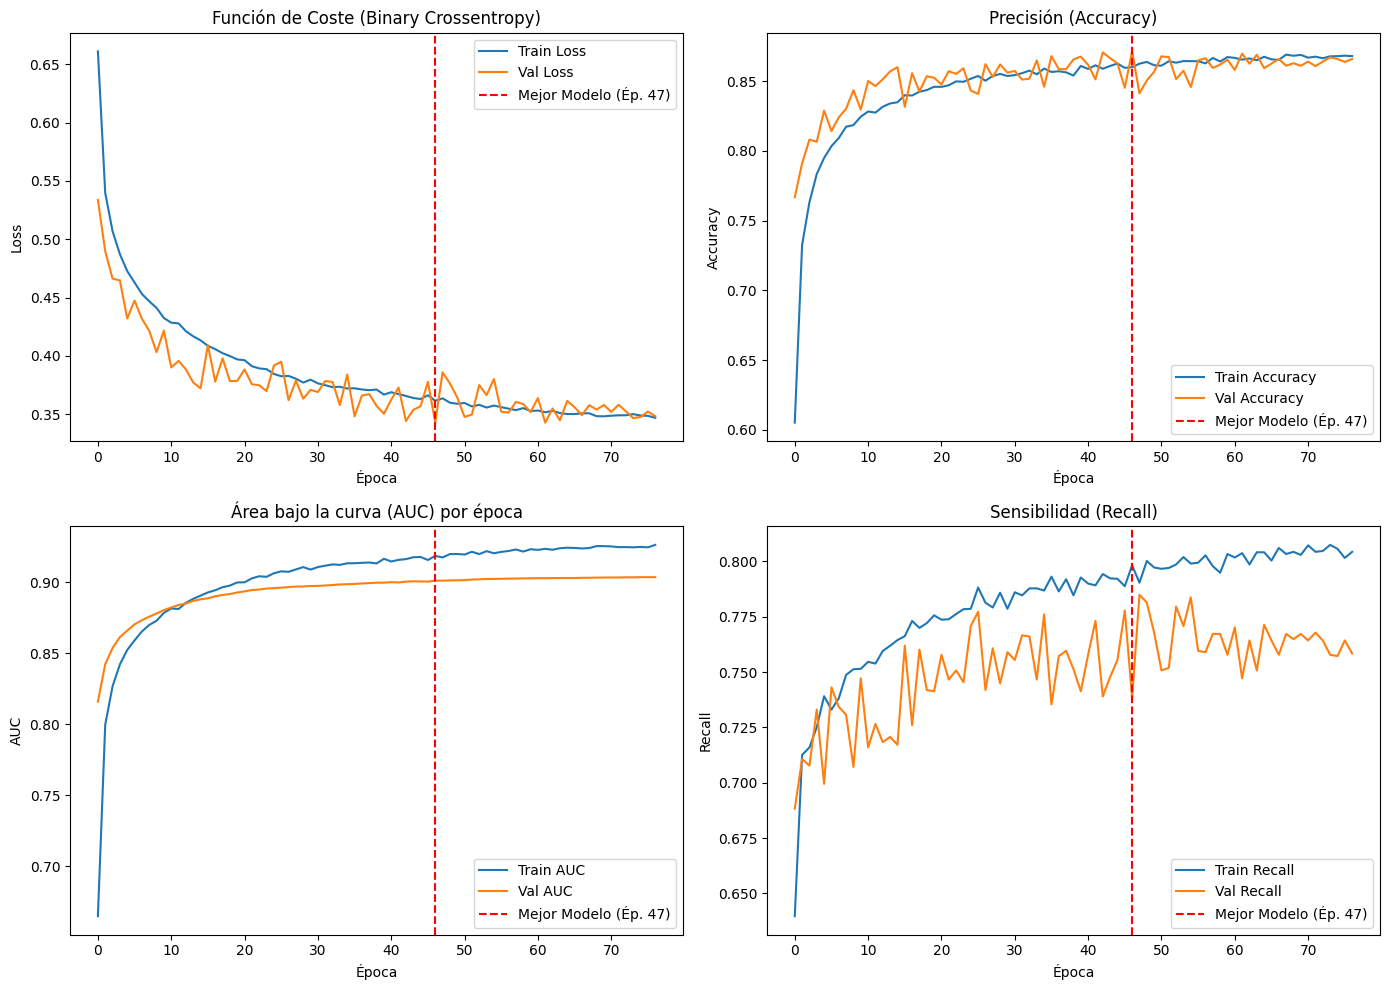


Evaluando el mejor modelo guardado (Época 47)...
351/351 ━━━━━━━━━━━━━━━━━━━━ 37s 105ms/step - accuracy: 0.8790 - auc: 0.9107 - loss: 0.3334 - precision: 0.5753 - recall: 0.7655

Métricas de Test -> Loss: 0.3334 | Accuracy: 0.8790 | Recall: 0.7655 | Precision: 0.5753 | AUC: 0.9107
351/351 ━━━━━━━━━━━━━━━━━━━━ 46s 117ms/step


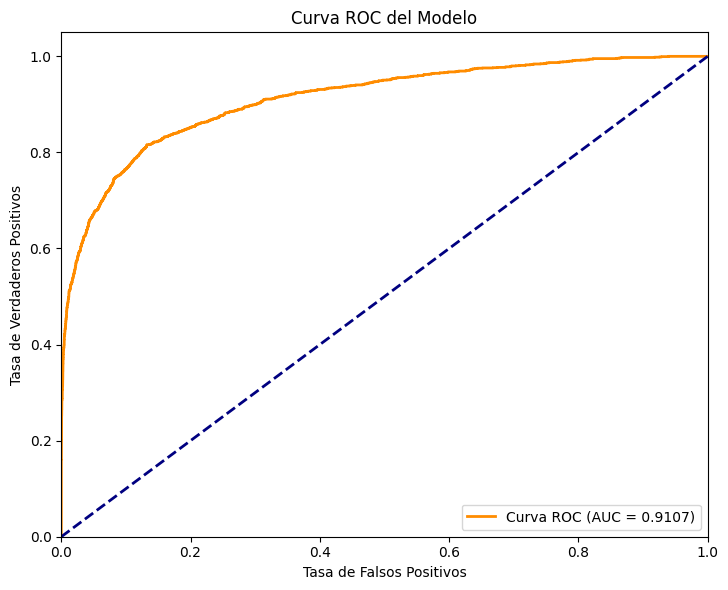

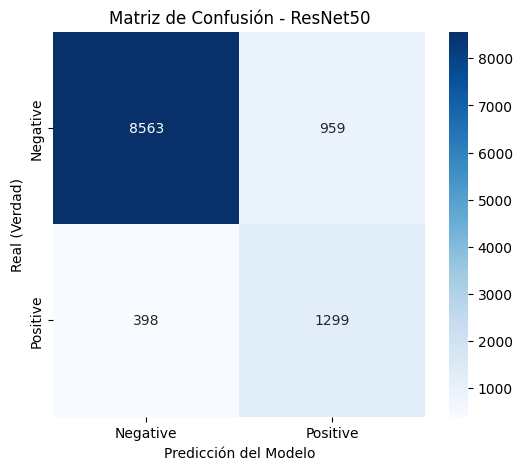


Reporte de Clasificación:
              precision    recall  f1-score   support

    Negative       0.96      0.90      0.93      9522
    Positive       0.58      0.77      0.66      1697

    accuracy                           0.88     11219
   macro avg       0.77      0.83      0.79     11219
weighted avg       0.90      0.88      0.89     11219



In [10]:
# Cargamos el modelo en su mejor punto, teniendo en cuenta el acccuracy
model.load_weights('best_resnet_model_3.keras')

# leemos el historial del csv
history = pd.read_csv('historial_entrenamiento_3.csv')

# Buscamos el índice de la época con el mayor val_accuracy
best_epoch_idx = np.argmax(history['val_accuracy'])

# 1. CURVAS DE CONVERGENCIA DEL ENTRENAMIENTO
plt.figure(figsize=(14, 10))

# Gráfica de Loss
plt.subplot(2, 2, 1)
plt.plot(history['loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Val Loss')
plt.axvline(x=best_epoch_idx, color='r', linestyle='--', label=f'Mejor Modelo (Ép. {best_epoch_idx + 1})')
plt.title('Función de Coste (Binary Crossentropy)')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.legend()

# Gráfica de Accuracy
plt.subplot(2, 2, 2)
plt.plot(history['accuracy'], label='Train Accuracy')
plt.plot(history['val_accuracy'], label='Val Accuracy')
plt.axvline(x=best_epoch_idx, color='r', linestyle='--', label=f'Mejor Modelo (Ép. {best_epoch_idx + 1})')
plt.title('Precisión (Accuracy)')
plt.xlabel('Época')
plt.ylabel('Accuracy')
plt.legend()

# Gráfica de AUC
plt.subplot(2, 2, 3)
plt.plot(history['auc'], label='Train AUC')
plt.plot(history['val_auc'], label='Val AUC')
plt.axvline(x=best_epoch_idx, color='r', linestyle='--', label=f'Mejor Modelo (Ép. {best_epoch_idx + 1})')
plt.title('Área bajo la curva (AUC) por época')
plt.xlabel('Época')
plt.ylabel('AUC')
plt.legend()

# Gráfica de Recall
plt.subplot(2, 2, 4)
plt.plot(history['recall'], label='Train Recall')
plt.plot(history['val_recall'], label='Val Recall')
plt.axvline(x=best_epoch_idx, color='r', linestyle='--', label=f'Mejor Modelo (Ép. {best_epoch_idx + 1})')
plt.title('Sensibilidad (Recall)')
plt.xlabel('Época')
plt.ylabel('Recall')
plt.legend()

plt.tight_layout()
plt.show()

# 2. PREDICCIONES Y EVALUACIÓN
print(f"\nEvaluando el mejor modelo guardado (Época {best_epoch_idx + 1})...")
eval_results = model.evaluate(test_gen, verbose=1)

print(f"\nMétricas de Test -> Loss: {eval_results[0]:.4f} | Accuracy: {eval_results[1]:.4f} | Recall: {eval_results[2]:.4f} | Precision: {eval_results[3]:.4f} | AUC: {eval_results[4]:.4f}")

predictions = model.predict(test_gen)
y_pred = (predictions > 0.5).astype(int).flatten()
y_true = test_gen.classes

# 3. CURVA ROC
plt.figure(figsize=(14, 6))
fpr, tpr, thresholds = roc_curve(y_true, predictions)
roc_auc = auc(fpr, tpr)
plt.subplot(1, 2, 1)
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Curva ROC (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos')
plt.title('Curva ROC del Modelo')
plt.legend(loc="lower right")

plt.tight_layout()
plt.show()

# 4. MATRIZ DE CONFUSIÓN Y REPORTE
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=test_gen.class_indices.keys(),
            yticklabels=test_gen.class_indices.keys())
plt.title('Matriz de Confusión - ResNet50')
plt.ylabel('Real (Verdad)')
plt.xlabel('Predicción del Modelo')
plt.show()

print("\nReporte de Clasificación:")
print(classification_report(y_true, y_pred, target_names=test_gen.class_indices.keys()))

Extrayendo mapas de características de la capa: conv1_conv


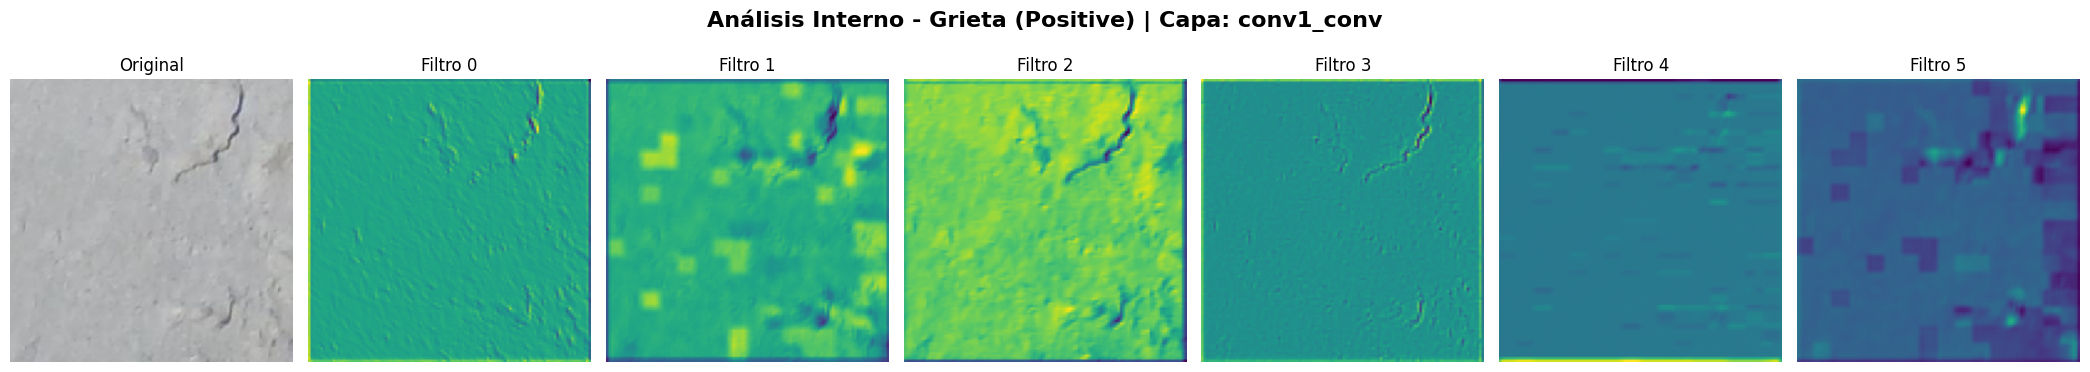

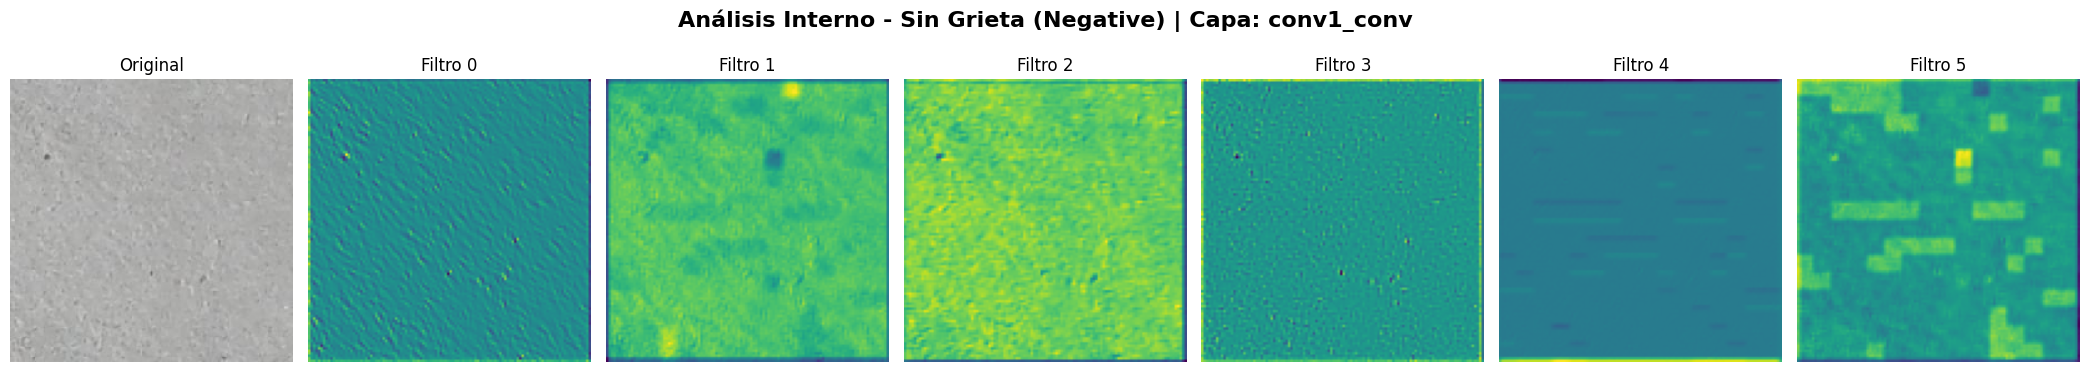

In [11]:
positive_dir = SPLIT_DIR / 'test' / 'Positive'
negative_dir = SPLIT_DIR / 'test' / 'Negative'
sample_positive_path = sorted(positive_dir.glob('*.jpg'))[5]
sample_negative_path = sorted(negative_dir.glob('*.jpg'))[5]

# Buscamos la primera capa convolucional
capa_base = model.layers[0]
if isinstance(capa_base, tf.keras.Model):
    conv_layer = [layer for layer in capa_base.layers if isinstance(layer, tf.keras.layers.Conv2D)][0]
    visual_model = Model(inputs=capa_base.inputs, outputs=conv_layer.output)
    es_resnet = True
else:
    conv_layer = [layer for layer in model.layers if isinstance(layer, tf.keras.layers.Conv2D)][0]
    visual_model = Model(inputs=model.inputs, outputs=conv_layer.output)
    es_resnet = False

print(f"Extrayendo mapas de características de la capa: {conv_layer.name}")
num_filtros = min(6, conv_layer.filters)
muestras = [
    (sample_positive_path, 'Grieta (Positive)'),
    (sample_negative_path, 'Sin Grieta (Negative)')]
for path, label in muestras:
    # Cargar imagen original para mostrarla
    img_raw = load_img(path, target_size=(227, 227))
    img_array = img_to_array(img_raw)
    if es_resnet:
        img_procesada = preprocess_input(img_array.copy())
    else:
        img_procesada = img_array.copy() / 255.0
    img_batch = np.expand_dims(img_procesada, axis=0)
    # Extraer los mapas de características
    feature_maps = visual_model.predict(img_batch, verbose=0)
    fig, axes = plt.subplots(1, num_filtros + 1, figsize=(3 * (num_filtros + 1), 4))
    fig.suptitle(f"Análisis Interno - {label} | Capa: {conv_layer.name}", fontsize=16, fontweight='bold')
    axes[0].imshow(img_raw)
    axes[0].set_title("Original", fontsize=12)
    axes[0].axis('off')
    # Dibujar los mapas de características
    for i in range(num_filtros):
        axes[i + 1].imshow(feature_maps[0, :, :, i], cmap='viridis')
        axes[i + 1].set_title(f"Filtro {i}", fontsize=12)
        axes[i + 1].axis('off')
    plt.tight_layout()
    plt.show()